In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load the dataset
# encoding='latin-1' is needed because the file isn't UTF-8
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Show the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
# Drop the junk empty columns
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Rename to meaningful names
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

# Check the result
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Shape:", df.shape)          # (rows, columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nLabel counts:\n", df['label'].value_counts())

Shape: (5572, 2)

Missing values:
 label      0
message    0
dtype: int64

Label counts:
 label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# Convert text labels to numbers: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


visualize the data 

C:\Users\gokul\AppData\Local\Temp\ipykernel_18248\1175322313.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])


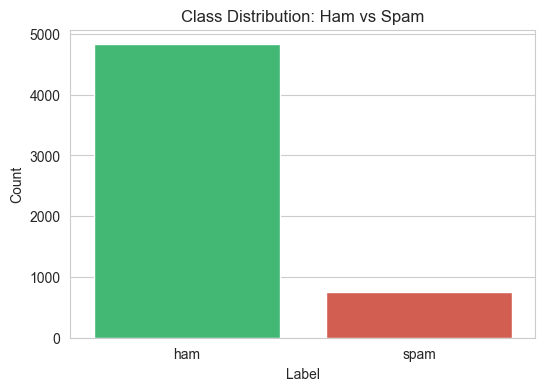

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_style('whitegrid')

# Count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Also show as percentages
print(df['label'].value_counts(normalize=True) * 100)

In [6]:
# Create a new feature: message length in characters
df['length'] = df['message'].apply(len)

df.head()

,label,message,label_num,length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


In [7]:
# Statistics by class
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


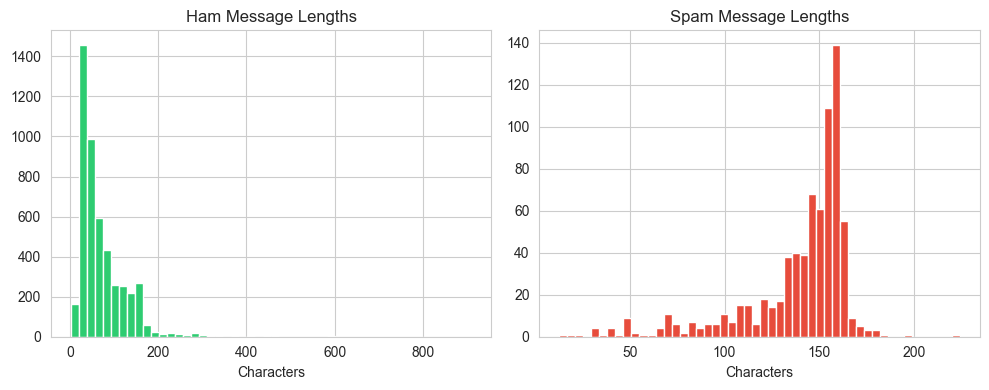

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df[df['label'] == 'ham']['length'].hist(bins=50, color='#2ecc71')
plt.title('Ham Message Lengths')
plt.xlabel('Characters')

plt.subplot(1, 2, 2)
df[df['label'] == 'spam']['length'].hist(bins=50, color='#e74c3c')
plt.title('Spam Message Lengths')
plt.xlabel('Characters')

plt.tight_layout()
plt.show()

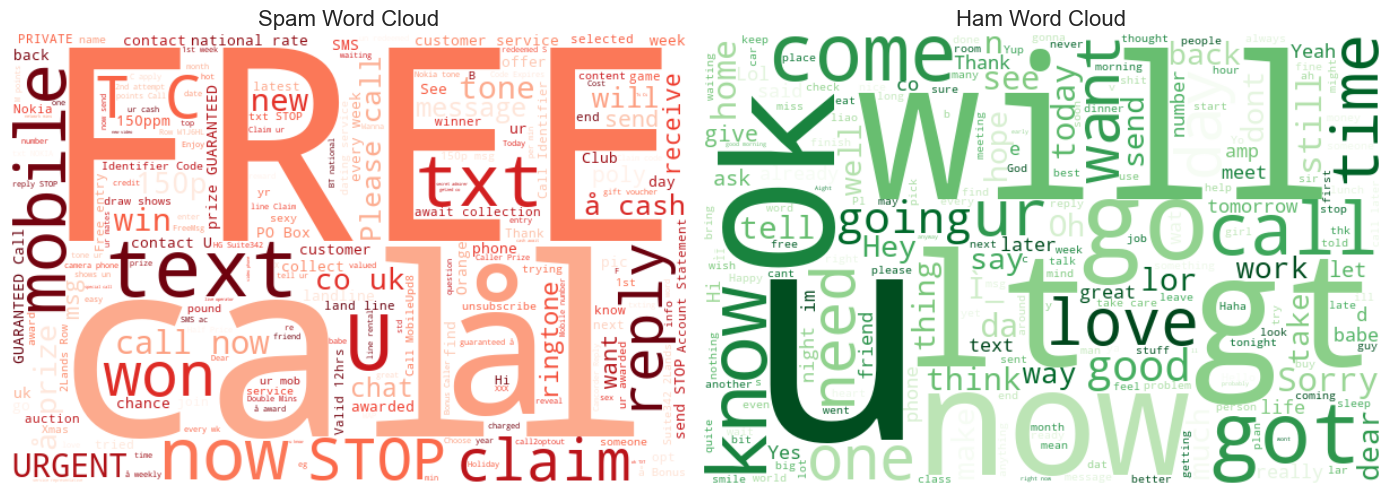

In [9]:
from wordcloud import WordCloud

# Combine all spam messages into one big string
spam_text = ' '.join(df[df['label'] == 'spam']['message'])
ham_text = ' '.join(df[df['label'] == 'ham']['message'])

# Generate word clouds
spam_wc = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(spam_text)
ham_wc = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(ham_text)

# Plot side by side
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Spam Word Cloud', fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Ham Word Cloud', fontsize=16)

plt.tight_layout()
plt.show()

In [10]:
plt.savefig('../wordcloud.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [11]:
print("Duplicates:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates(keep='first')
print("Shape after dropping:", df.shape)

Duplicates: 403
Shape after dropping: (5169, 4)


## EDA Findings

1. **Class imbalance**: Dataset is 87% ham, 13% spam. We must use F1-score / precision / recall, not accuracy.
2. **Message length**: Spam messages average 138 characters vs 71 for ham — nearly 2× longer.
3. **Vocabulary differences**: Spam features promotional words (FREE, WIN, CALL, CLAIM); ham is conversational (ok, love, gonna).
4. **Duplicates**: ~400 duplicate rows removed to prevent data leakage.
5. **No missing values**: Clean dataset, ready for preprocessing.

In [12]:
# Save the cleaned dataframe so the next notebook can use it
df.to_csv('../data/spam_cleaned.csv', index=False)
print("Saved cleaned data!")

Saved cleaned data!
